# Genetic Programming: Evolving a Mathematical Expression

## What are we doing?

In the previous genetic-algorithm example, each candidate solution was a pair of numbers:

```text
chromosome = [x, y]
```

The GA searched for values that minimized a benchmark function.

In **genetic programming (GP)**, we change one important idea:

> Instead of evolving numbers, we evolve **programs**.

For this first example, the programs are small mathematical expressions such as:

```text
x
x + 1
x * x
(x * x) + x
```

Our goal is to evolve an expression that matches a known set of input/output examples.

This problem is called **symbolic regression**.

---

## The benchmark problem

We will generate data from the classic symbolic-regression target

\[
y = x^4 + x^3 + x^2 + x
\]

and then **hide that equation from the GP**.

The GP receives only pairs of numbers:

```text
x  →  y
```

It must search for an expression whose predictions match those examples.

---

## Learning goals

By the end of this notebook, you should be able to:

1. Explain the difference between a genetic algorithm and genetic programming.
2. Represent a mathematical expression as a tree.
3. Evaluate an expression tree on data.
4. Explain how selection, crossover, mutation, and elitism work in GP.
5. Explain why subtree crossover is different from ordinary GA crossover.
6. Read a GP convergence plot.
7. Modify the function set or GP parameters and observe how evolution changes.

---

## GA versus GP

| Genetic Algorithm | Genetic Programming |
|---|---|
| Evolves a fixed representation | Evolves programs or expressions |
| Chromosome might be `[x, y]` | Individual might be `(x * x) + x` |
| Crossover swaps genes | Crossover swaps **subtrees** |
| Mutation changes a gene | Mutation replaces a **subtree** |
| Search space = parameter values | Search space = possible programs |

The evolutionary idea is the same:

```text
Create random candidates
        ↓
Evaluate them
        ↓
Select promising parents
        ↓
Crossover
        ↓
Mutation
        ↓
Create next generation
        ↓
      repeat
```

The main difference is **what evolves**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# One random-number generator makes our experiments reproducible.
rng = np.random.default_rng(seed=42)

## 1. Create the benchmark data

The target function is:

\[
f(x) = x^4 + x^3 + x^2 + x
\]

We sample points between -1 and 1.

In a real symbolic-regression problem, we would not know the equation that generated the data. We use a known benchmark here because it lets us check whether GP is behaving sensibly.

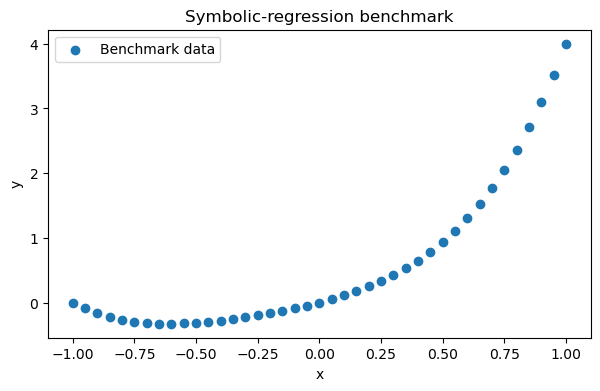

In [2]:
def target_function(x):
    """The hidden function that generates our benchmark data."""
    return x**4 + x**3 + x**2 + x

# Data available to the GP.
X = np.linspace(-1.0, 1.0, 41)
y = target_function(X)

plt.figure(figsize=(7, 4))
plt.scatter(X, y, label="Benchmark data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Symbolic-regression benchmark")
plt.legend()
plt.show()

## 2. Represent a program as a tree

A mathematical expression naturally forms a tree.

For example:

```text
        +
       / \
      *   x
     / \
    x   x
```

represents

\[
(x \times x) + x
\]

The leaves are called **terminals**. In this example, terminals can be:

- the input variable `x`
- small numerical constants

The internal nodes are **functions**. To keep our first GP simple, we use only:

- addition `+`
- subtraction `-`
- multiplication `*`

A tree in Python will be stored as a nested tuple:

```python
("+", ("*", "x", "x"), "x")
```

This representation is intentionally simple so we can see exactly what GP is doing.

In [3]:
# Functions that GP is allowed to use.
FUNCTIONS = ("+", "-", "*")

# Small constants that GP may place in expression trees.
CONSTANTS = (-2.0, -1.0, 0.0, 1.0, 2.0)

def is_function(tree):
    """Return True when a tree node is a function such as +, -, or *."""
    return isinstance(tree, tuple)

def make_terminal():
    """Create a random terminal: usually x, sometimes a constant."""
    if rng.random() < 0.7:
        return "x"
    return float(rng.choice(CONSTANTS))

def random_tree(max_depth, current_depth=0):
    """Create a random expression tree.

    As we get deeper into the tree, we become more likely to stop
    and create a terminal. This helps keep initial trees small.
    """
    if current_depth >= max_depth or rng.random() < 0.30:
        return make_terminal()

    operator = rng.choice(FUNCTIONS)

    left = random_tree(max_depth, current_depth + 1)
    right = random_tree(max_depth, current_depth + 1)

    return (operator, left, right)

### Read a tree as an expression

Before running evolution, it helps to be able to print a tree in familiar mathematical notation.

In [4]:
def tree_to_string(tree):
    """Convert an expression tree into a readable mathematical string."""
    if not is_function(tree):
        if tree == "x":
            return "x"
        return f"{tree:g}"

    operator, left, right = tree

    return (
        f"({tree_to_string(left)} "
        f"{operator} "
        f"{tree_to_string(right)})"
    )

example_tree = random_tree(max_depth=3)

print("Tree representation:")
print(example_tree)

print("\nAs an expression:")
print(tree_to_string(example_tree))

Tree representation:
(np.str_('-'), (np.str_('-'), (np.str_('+'), -2.0, 1.0), 'x'), (np.str_('*'), (np.str_('*'), 1.0, 'x'), 'x'))

As an expression:
(((-2 + 1) - x) - ((1 * x) * x))


## 3. Execute an evolved program

A GP tree is not just a data structure. It represents a program that we can execute.

Evaluation works recursively:

```text
          +
        /   \
       *     x
      / \
     x   x

evaluate *
    ↓
x * x

evaluate +
    ↓
(x * x) + x
```

Because NumPy operations work on arrays, one tree can make predictions for every `x` value at once.

In [5]:
def evaluate_tree(tree, x):
    """Evaluate an expression tree for one value or an array of x values."""
    if not is_function(tree):
        if tree == "x":
            return x
        return np.full_like(x, tree, dtype=float)

    operator, left, right = tree

    left_value = evaluate_tree(left, x)
    right_value = evaluate_tree(right, x)

    if operator == "+":
        return left_value + right_value

    if operator == "-":
        return left_value - right_value

    if operator == "*":
        return left_value * right_value

    raise ValueError(f"Unknown operator: {operator}")

example_predictions = evaluate_tree(example_tree, X)

print("Expression:")
print(tree_to_string(example_tree))

print("\nFirst five predictions:")
print(example_predictions[:5])

Expression:
(((-2 + 1) - x) - ((1 * x) * x))

First five predictions:
[-1.     -0.9525 -0.91   -0.8725 -0.84  ]


## 4. Fitness: how good is a program?

For each expression tree:

```text
expression tree
       ↓
predict y for every x
       ↓
compare predictions with benchmark data
       ↓
mean squared error (MSE)
       ↓
lower is better
```

We use **mean squared error**:

\[
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
\]

A perfect expression would have an MSE of 0.

This is the GP equivalent of the objective function in our previous GA benchmark example.

In [6]:
def fitness(tree, X, y):
    """Return mean squared error for one expression tree.

    Lower fitness values are better.
    """
    predictions = evaluate_tree(tree, X)
    return np.mean((y - predictions) ** 2)


print(f"Example tree fitness: {fitness(example_tree, X, y):.6f}")

Example tree fitness: 6.962572


## 5. Create a population

A GP population is a collection of randomly generated expression trees.

The trees do **not** all have the same shape or size.

That is another important difference from a basic genetic algorithm: GP individuals can have variable structure.

In [7]:
def initialize_population(population_size, max_initial_depth=3):
    """Create a population of random expression trees."""
    return [
        random_tree(max_depth=max_initial_depth)
        for _ in range(population_size)
    ]


population = initialize_population(5)

for i, tree in enumerate(population, start=1):
    print(f"{i}: {tree_to_string(tree)}")

1: -1
2: (((1 * x) + x) - ((x - x) + (x * x)))
3: (((2 + x) + (x - x)) + (x * 1))
4: (((x - x) - (x - 0)) - ((x - x) - (x * -1)))
5: x


## 6. Selection: choose promising programs

We again use **tournament selection**, just as we did in the GA example.

```text
Tree A: MSE = 2.40
Tree B: MSE = 0.18   ← winner
Tree C: MSE = 1.25
```

Because lower MSE is better, Tree B wins the tournament.

The selection idea did not change.

Only the representation changed.

In [8]:
def tournament_selection(population, fitness_values, tournament_size=3):
    """Choose one parent using tournament selection."""
    candidate_indices = rng.choice(
        len(population),
        size=tournament_size,
        replace=False,
    )

    winner_index = candidate_indices[
        np.argmin(fitness_values[candidate_indices])
    ]

    return population[winner_index]

## 7. Finding subtrees

GA crossover usually chooses positions in a chromosome.

GP crossover needs to choose **parts of a tree**.

We represent a location in a tree using a path:

```text
()        = the whole tree
(0,)      = left child
(1,)      = right child
(0, 1)    = right child of the left child
```

The helper functions below let us:

1. list every possible subtree location,
2. retrieve a subtree,
3. replace a subtree.

These utilities make crossover and mutation much easier to read.

In [9]:
def all_paths(tree, path=()):
    """Return paths to every node in a tree."""
    paths = [path]

    if is_function(tree):
        _, left, right = tree
        paths.extend(all_paths(left, path + (0,)))
        paths.extend(all_paths(right, path + (1,)))

    return paths


def get_subtree(tree, path):
    """Return the subtree stored at a path."""
    if not path:
        return tree

    operator, left, right = tree

    if path[0] == 0:
        return get_subtree(left, path[1:])

    return get_subtree(right, path[1:])


def replace_subtree(tree, path, replacement):
    """Return a copy of tree with one subtree replaced."""
    if not path:
        return replacement

    operator, left, right = tree

    if path[0] == 0:
        return (
            operator,
            replace_subtree(left, path[1:], replacement),
            right,
        )

    return (
        operator,
        left,
        replace_subtree(right, path[1:], replacement),
    )

## 8. Crossover: swap pieces of programs

This is the defining GP operator.

Suppose we have:

```text
Parent 1                  Parent 2

    +                         -
   / \                       / \
  *   x                     x   1
 / \
x   x
```

We can choose a subtree from Parent 2 and insert it into Parent 1.

For example, replacing the left `x * x` subtree gives a child such as:

```text
      +
     / \
    -   x
   / \
  x   1
```

Instead of swapping individual genes, GP recombines **pieces of executable structure**.

In [10]:
def tree_depth(tree):
    """Return the depth of an expression tree."""
    if not is_function(tree):
        return 0

    _, left, right = tree
    return 1 + max(tree_depth(left), tree_depth(right))


def crossover(parent1, parent2, max_depth=6):
    """Create a child by inserting a subtree from parent2 into parent1."""
    path1 = all_paths(parent1)[rng.integers(len(all_paths(parent1)))]
    path2 = all_paths(parent2)[rng.integers(len(all_paths(parent2)))]

    donor_subtree = get_subtree(parent2, path2)
    child = replace_subtree(parent1, path1, donor_subtree)

    # Prevent trees from growing without bound.
    if tree_depth(child) > max_depth:
        return parent1

    return child

## 9. Mutation: replace a subtree

Mutation introduces new program structure.

```text
Before:

      +
     / \
    *   x
   / \
  x   x

Replace one subtree with a random new tree:

      +
     / \
    *   x
   / \
  x   1
```

Unlike the GA example, mutation can change both the **values** and the **shape** of an individual.

In [11]:
def mutate(tree, mutation_rate=0.10, max_depth=6):
    """Occasionally replace one subtree with a new random subtree."""
    if rng.random() >= mutation_rate:
        return tree

    paths = all_paths(tree)
    mutation_path = paths[rng.integers(len(paths))]

    new_subtree = random_tree(max_depth=2)
    mutated = replace_subtree(tree, mutation_path, new_subtree)

    if tree_depth(mutated) > max_depth:
        return tree

    return mutated

## 10. Put the GP pieces together

The overall evolutionary loop should look familiar:

```text
Create random expression trees

Repeat for each generation:

    Evaluate every tree

    Remember the best tree

    Keep the best tree
        (elitism)

    While the new population is not full:
        Select parent 1
        Select parent 2
        Subtree crossover
        Subtree mutation
        Add child

    Replace the old population
```

This is almost the same evolutionary loop as our GA.

The major difference is that the individuals are now **program trees**.

In [12]:
def run_gp(
    X,
    y,
    population_size=150,
    generations=60,
    mutation_rate=0.10,
    tournament_size=3,
    max_initial_depth=3,
    max_tree_depth=6,
):
    """Run a simple genetic-programming symbolic-regression search."""
    population = initialize_population(
        population_size,
        max_initial_depth=max_initial_depth,
    )

    history = {"best": [], "mean": []}
    best_tree = None
    best_fitness = np.inf

    # Keep a few of the best trees from each generation for visualization.
    top_trees_history = []

    for generation in range(generations):
        fitness_values = np.array([
            fitness(tree, X, y)
            for tree in population
        ])

        ranked_indices = np.argsort(fitness_values)

        generation_best = population[ranked_indices[0]]
        generation_best_fitness = fitness_values[ranked_indices[0]]

        if generation_best_fitness < best_fitness:
            best_tree = generation_best
            best_fitness = generation_best_fitness

        history["best"].append(best_fitness)
        history["mean"].append(np.mean(fitness_values))

        top_trees_history.append([
            population[i]
            for i in ranked_indices[:3]
        ])

        # Elitism: preserve the best program in this generation.
        next_population = [generation_best]

        while len(next_population) < population_size:
            parent1 = tournament_selection(
                population,
                fitness_values,
                tournament_size,
            )

            parent2 = tournament_selection(
                population,
                fitness_values,
                tournament_size,
            )

            child = crossover(
                parent1,
                parent2,
                max_depth=max_tree_depth,
            )

            child = mutate(
                child,
                mutation_rate=mutation_rate,
                max_depth=max_tree_depth,
            )

            next_population.append(child)

        population = next_population

    return best_tree, best_fitness, history, top_trees_history

## 11. Run genetic programming

These are the main parameters we will start with:

- **Population size** — number of candidate programs.
- **Generations** — number of evolutionary rounds.
- **Mutation rate** — probability that a child receives subtree mutation.
- **Tournament size** — strength of selection.
- **Maximum tree depth** — limits program growth.

Before running the cell, make a prediction:

> Will GP discover the exact target equation, a mathematically equivalent equation, or simply a good approximation?

All three outcomes are possible.

In [13]:
POPULATION_SIZE = 150
GENERATIONS = 60
MUTATION_RATE = 0.10
TOURNAMENT_SIZE = 3
MAX_TREE_DEPTH = 6

best_tree, best_fitness, history, top_trees_history = run_gp(
    X,
    y,
    population_size=POPULATION_SIZE,
    generations=GENERATIONS,
    mutation_rate=MUTATION_RATE,
    tournament_size=TOURNAMENT_SIZE,
    max_tree_depth=MAX_TREE_DEPTH,
)

print("Best evolved expression:")
print(tree_to_string(best_tree))

print(f"\nMSE: {best_fitness:.8f}")
print(f"Tree depth: {tree_depth(best_tree)}")

Best evolved expression:
(x + (x * ((((x * x) + x) * x) + x)))

MSE: 0.00000000
Tree depth: 6


## 12. Did evolution improve the programs?

Because MSE is an error measure, **down is good**.

The best-so-far curve should never increase because we use elitism.

The population mean can move up or down because crossover and mutation continue to create new programs.

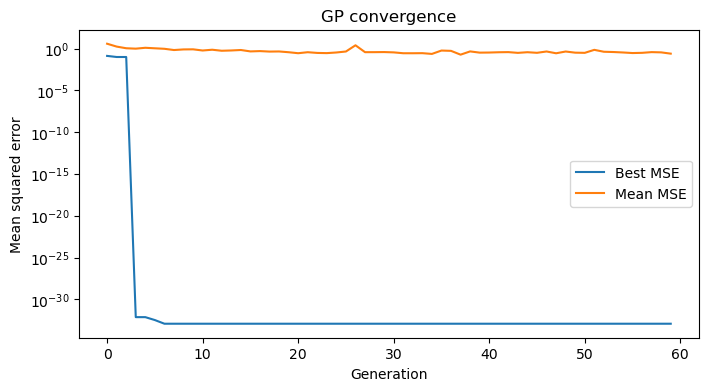

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(history["best"], label="Best MSE")
plt.plot(history["mean"], label="Mean MSE")
plt.xlabel("Generation")
plt.ylabel("Mean squared error")
plt.title("GP convergence")
plt.yscale("log")
plt.legend()
plt.show()

## 13. Compare the evolved program with the benchmark data

A low MSE is useful, but we should also look at what the evolved expression actually does.

The next plot compares:

- the original benchmark data,
- predictions from the best evolved expression.

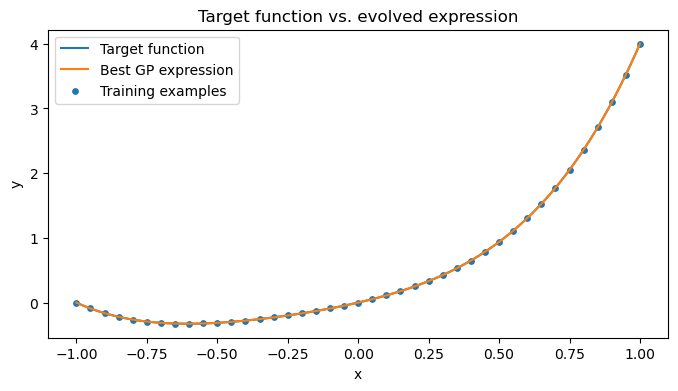

In [15]:
x_plot = np.linspace(-1.0, 1.0, 300)

target_plot = target_function(x_plot)
gp_plot = evaluate_tree(best_tree, x_plot)

plt.figure(figsize=(8, 4))
plt.plot(x_plot, target_plot, label="Target function")
plt.plot(x_plot, gp_plot, label="Best GP expression")
plt.scatter(X, y, s=15, label="Training examples")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Target function vs. evolved expression")
plt.legend()
plt.show()

## 14. Visualize expression trees

The code below draws a GP tree without requiring a graph-visualization library.

This is useful because a symbolic expression is easier to understand when we can see its structure.

We will also use this drawing function for the animation.

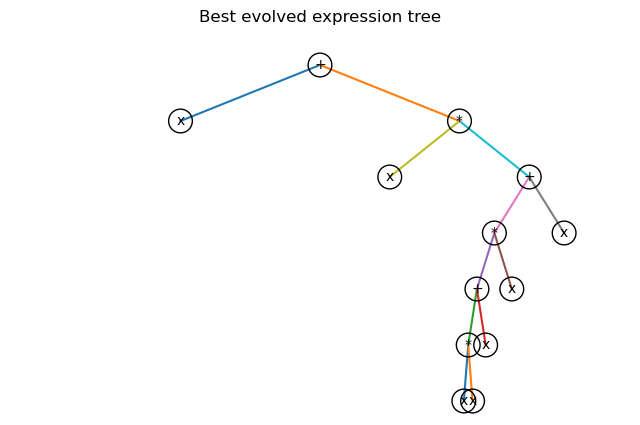

In [16]:
def node_label(tree):
    """Return the label displayed for one tree node."""
    if is_function(tree):
        return tree[0]

    if tree == "x":
        return "x"

    return f"{tree:g}"


def tree_layout(tree, x=0.5, y=1.0, width=0.45, level_gap=0.18):
    """Return node positions and edges for a simple binary-tree drawing."""
    nodes = []
    edges = []

    def visit(subtree, node_x, node_y, node_width):
        node_id = len(nodes)
        nodes.append((node_id, node_x, node_y, node_label(subtree)))

        if is_function(subtree):
            _, left, right = subtree

            left_x = node_x - node_width / 2
            right_x = node_x + node_width / 2
            child_y = node_y - level_gap

            left_id = visit(left, left_x, child_y, node_width / 2)
            right_id = visit(right, right_x, child_y, node_width / 2)

            edges.append((node_id, left_id))
            edges.append((node_id, right_id))

        return node_id

    visit(tree, x, y, width)
    return nodes, edges


def draw_tree(tree, ax=None, y_offset=0.0, scale=1.0):
    """Draw one expression tree on an existing Matplotlib axis."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    nodes, edges = tree_layout(
        tree,
        x=0.5,
        y=1.0,
        width=0.45,
        level_gap=0.16,
    )

    positions = {
        node_id: (x, y_offset + scale * y)
        for node_id, x, y, _ in nodes
    }

    for parent, child in edges:
        x1, y1 = positions[parent]
        x2, y2 = positions[child]
        ax.plot([x1, x2], [y1, y2])

    for node_id, _, _, label in nodes:
        x, y = positions[node_id]
        ax.text(
            x,
            y,
            label,
            ha="center",
            va="center",
            bbox={"boxstyle": "circle,pad=0.35", "fill": False},
        )

    return ax


plt.figure(figsize=(8, 5))
ax = plt.gca()
draw_tree(best_tree, ax=ax)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.1)
ax.axis("off")
ax.set_title("Best evolved expression tree")
plt.show()

## 15. Animate a few trees as evolution proceeds

The animation below shows the **three best trees in each displayed generation**.

Read it as a structural view of evolution:

- branches appear and disappear,
- subtrees are reused,
- expressions may become larger or smaller,
- different structures can produce very similar behavior.

Do not expect tree structure to change smoothly. GP evolution happens through discrete subtree replacements.

For readability, the animation samples generations rather than displaying every one.

In [17]:
def draw_tree_in_band(tree, ax, band_bottom, band_top):
    """Draw one tree inside a vertical band of a single axis."""
    nodes, edges = tree_layout(
        tree,
        x=0.5,
        y=1.0,
        width=0.42,
        level_gap=0.15,
    )

    height = band_top - band_bottom

    positions = {
        node_id: (
            x,
            band_bottom + 0.08 * height + 0.84 * height * y,
        )
        for node_id, x, y, _ in nodes
    }

    for parent, child in edges:
        x1, y1 = positions[parent]
        x2, y2 = positions[child]
        ax.plot([x1, x2], [y1, y2])

    for node_id, _, _, label in nodes:
        x, y = positions[node_id]
        ax.text(
            x,
            y,
            label,
            ha="center",
            va="center",
            fontsize=9,
            bbox={"boxstyle": "circle,pad=0.28", "fill": False},
        )


def animate_top_trees(top_trees_history, every=3, interval_ms=600):
    """Animate the three best expression trees over GP generations."""
    frames = list(range(0, len(top_trees_history), every))

    if frames[-1] != len(top_trees_history) - 1:
        frames.append(len(top_trees_history) - 1)

    fig, ax = plt.subplots(figsize=(8, 9))

    def update(frame_number):
        generation = frames[frame_number]
        trees = top_trees_history[generation]

        ax.clear()
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 3)
        ax.axis("off")
        ax.set_title(
            f"Three best GP trees — generation {generation}"
        )

        for rank, tree in enumerate(trees):
            bottom = 2 - rank
            top = 3 - rank

            ax.text(
                0.02,
                top - 0.12,
                f"Rank {rank + 1}",
                ha="left",
                va="top",
            )

            draw_tree_in_band(
                tree,
                ax,
                band_bottom=bottom,
                band_top=top,
            )

        return []

    animation = FuncAnimation(
        fig,
        update,
        frames=len(frames),
        interval=interval_ms,
        blit=False,
    )

    plt.close(fig)
    return HTML(animation.to_jshtml())


# Uncomment to watch tree structure evolve:
# animate_top_trees(top_trees_history)

# What just happened?

This is the central idea of genetic programming:

> **Evolution searched over programs rather than over fixed numerical parameters.**

We started with randomly generated expression trees.

For each generation, GP:

1. **executed** each tree on the benchmark inputs,
2. measured its **mean squared error**,
3. used **selection** to favor lower-error programs,
4. used **subtree crossover** to recombine pieces of programs,
5. used **subtree mutation** to create new program structures,
6. preserved the best program using **elitism**,
7. repeated the process.

The result is an expression that was *discovered through search*.

---

## An important difference from ordinary machine learning

In many ML algorithms, the **model structure is fixed** and training adjusts numerical parameters.

For example, linear regression starts with a model form such as

\[
y = b_0 + b_1x
\]

and learns the numerical values of \(b_0\) and \(b_1\).

In this GP example, even the **structure of the mathematical expression evolves**.

GP can decide to use:

```text
x
x * x
x + (x * x)
((x * x) + x) * x
...
```

That ability to search over structure is what makes genetic programming distinctive.

# Experiments

## First experiments

Before running each experiment, make a prediction.

1. Change the random seed. Do you get the same expression?
2. Try population sizes of 25, 75, 150, and 300.
3. Try mutation rates of 0, 0.05, 0.20, and 0.50.
4. Try 10 generations versus 100 generations.
5. Change tournament size. What happens when selection becomes stronger?
6. Change `MAX_TREE_DEPTH`. Does allowing larger trees always help?

## Change the language GP can use

Try modifying:

```python
FUNCTIONS = ("+", "-", "*")
```

What happens if you remove subtraction?

What happens if you add division?

If you add division, think carefully about what should happen when the denominator is zero. GP often uses a **protected division** operator for this reason.

## Change the benchmark

Replace the target function with something else, for example:

\[
y = x^3 - 2x + 1
\]

or

\[
y = x^2 + 2x + 1
\]

Can GP rediscover a good expression?

## Questions to think about

- Why can two very different trees have nearly identical fitness?
- Why might GP produce a correct expression that looks more complicated than the original target?
- What causes trees to become unnecessarily large?
- How do crossover and mutation affect program structure differently?
- Why do we limit maximum tree depth?
- How could we modify fitness to reward both accuracy **and simplicity**?

# Challenge: accuracy versus simplicity

Our current fitness function rewards only prediction accuracy.

That means GP has no reason to prefer:

```text
x * x
```

over a much larger expression that behaves exactly the same way.

This can lead to **bloat**: trees grow larger without becoming meaningfully better.

One common idea is to penalize complexity:

\[
fitness = MSE + \lambda \times tree\_size
\]

where \(\lambda\) controls how much we value simplicity.

Try implementing this idea.

Then ask:

> Can you evolve an expression that is both accurate **and** easy to understand?

That question captures one of the most interesting reasons to use symbolic regression: the goal is often not merely prediction, but an interpretable model.